## Part 1

- images
    - 1.png
    - 2.png
    - ...
- labels 
    - 1.txt
    - 2.text
    - ...
- config.yaml

## Part 2

### how single-shot detectors such as YOLO are different from the R-CNN series

- Reframe object detection as a single regression problem, straight from image pixels to bounding box coordinates and class probabilities. Using our system, you only
look once (YOLO) at an image to predict what objects are
present and where they are.
- A single convolutional network simultaneously predicts multi-
ple bounding boxes and class probabilities for those boxes.
YOLO trains on full images and directly optimizes detec-
tion performance. 
- This unified model has several benefits
over traditional methods of object detectioFirst, YOLO is extremely fast. Since we frame detection
as a regression problem we don’t need a complex pipeline.
- We simply run our neural network on a new image at test
time to predict detections.Furthermore, YOLO
achieves more than twice the mean average precision of
other real-time systems.Second, YOLO reasons globally about the image when making predictions. 
- Unlike sliding window and region
proposal-based techniques, YOLO sees the entire image
during training and test time so it implicitly encodes contex-
tual information about classes as well as their appearance.Our system divides the input image into an S × S grid.
- If the center of an object falls into a grid cell, that grid cell
is responsible for detecting that object.Each grid cell predicts B bounding boxes and confidence
scores for those boxes. These confidence scores reflect how
confident the model is that the box contains an object and
also how accurate it thinks the box is that it predicts. 
- Formally we define confidence as Pr(Object) ∗ IOUtruth
pred . If no
object exists in that cell, the confidence scores should be
zero. Otherwise we want the confidence score to equal the
intersection over union (IOU) between the predicted box
and the ground truth.Each bounding box consists of 5 predictions: x, y, w, h,
and confidence. 
- The (x, y) coordinates represent the center
of the box relative to the bounds of the grid cell. The width
and height are predicted relative to the whole image. 
- Finally
the confidence prediction represents the IOU between the
predicted box and any ground truth box.YOLO predicts multiple bounding boxes per grid cell.
At training time we only want one bounding box predictor
to be responsible for each object. We assign one predictor
to be “responsible” for predicting an object based on which
prediction has the highest current IOU with the ground
truth. This leads to specialization between the bounding box
predictors. Each predictor gets better at predicting certain
sizes, aspect ratios, or classes of object, improving overall
recall.

### Differences between any three YOLO models

- YOLOv3 uses a custom architecture based on Darknet-53 as its backbone network, with additional layers for object detection.
YOLOv5 has a simplified architecture, often referred to as YOLOv5s, with a smaller model size compared to YOLOv3. It typically uses a more modern backbone architecture like CSPDarknet53 or MobileNetV3.
- YOLOv2, exhibited an impressive average precision (AP) of 78.6% on the PASCAL VOC2007 dataset, outperforming its predecessor, YOLOv1, which achieved only 63.4%. These findings highlight the advanced capabilities of YOLOv2 in object detection and recognition, paving the way for future progress in computer vision.
- When YOLOv3 was released, the benchmark for object detection had changed from PASCAL VOC to Microsoft COCO. From here on, all the YOLOs are evaluated in the MS COCO dataset. The YOLOv3-spp variant introduced in the paper achieved mAP of 60.6% at 20 FPS, achieving state-of-the-art at the time and 2x faster. As it turns out, this becomes the final YOLO version led by Joseph Redmon.
YOLOv5 builds upon many of the improvements made in YOLOv4, but the main difference is that it was developed using PyTorch instead of DarkNet.

- Ultralytics actively maintains YOLOv5 as an open-source project with over 250 contributors and frequent improvements. It is user-friendly for training, deployment, and implementation. In testing the MS COCO dataset test-dev 2017, YOLOv5x achieved an impressive AP of 50.7% with an image size of 640 pixels. With a batch size of 32, it can attain a speed of 200 FPS on an NVIDIA V100.
By using a larger input size of 1536 pixels, YOLOv5 can achieve an even higher AP of 55.8%.

In [3]:
!pip install ultralytics

In [ ]:
import ultralytics
ultralytics.checks()


Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 28.9/78.2 GB disk)


## Part 3

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO('yolov8n.yaml')  # build a new model from YAML
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model.train(data='/content/drive/MyDrive/archive/config.yaml', epochs=5, imgsz=400)

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=/content/drive/MyDrive/archive/config.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=400, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_co

100%|██████████| 755k/755k [00:00<00:00, 15.9MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/archive/labels/train.cache... 400 images, 0 backgrounds, 0 corrupt: 100%|██████████| 400/400 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


...

        5/5         0G      3.185      3.392      3.555         38        416: 100%|██████████| 25/25 [02:49<00:00,  6.80s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:08<00:00,  4.13s/it]

                   all         50         52    0.00565      0.615     0.0752     0.0162



5 epochs completed in 0.253 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLOv8n summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:06<00:00,  3.42s/it]


                   all         50         52    0.00925      0.365      0.089     0.0201
Speed: 1.3ms preprocess, 94.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train


### (i) How many parameters does this model have? How many convolutional layers does it use?

YOLOv8n summary: 225 layers, 3011043 parameters

### (ii) Compare the size (# parameters and # conv layers) of this model against yolov8m (medium) model.

295 layers, 25856899 parameters

In [ ]:
!scp /content/runs '/content/drive/MyDrive/archive/images'

## Part 4

In [ ]:
import os
import shutil
import random

dataset_path = '/content/drive/MyDrive/archive/'
images_path = os.path.join(dataset_path, 'images')
train_images_path = os.path.join(images_path, 'train')
train_labels_path = os.path.join(dataset_path, 'labels', 'train')
config_path = os.path.join(dataset_path, 'config.yaml')

train1_path = os.path.join(dataset_path, 'train1')
os.makedirs(train1_path, exist_ok=True)
train1_images_path = os.path.join(train1_path, 'images', 'train')
train1_labels_path = os.path.join(train1_path, 'labels', 'train')
os.makedirs(train1_images_path, exist_ok=True)
os.makedirs(train1_labels_path, exist_ok=True)

train2_path = os.path.join(dataset_path, 'train2')
if os.path.exists(train2_path):
    shutil.rmtree(train2_path)

shutil.copytree(dataset_path, train2_path)

image_files = os.listdir(train_images_path)

selected_images = random.sample(image_files, 100)

for image in selected_images:
    image_path = os.path.join(train_images_path, image)
    label_path = os.path.join(train_labels_path, os.path.splitext(image)[0] + '.txt')
    shutil.copy(image_path, train1_images_path)
    shutil.copy(label_path, train1_labels_path)

with open(config_path, 'r') as f:
    config_data = f.read()

config_data = config_data.replace('images/train', 'train1/images/train').replace('labels/train', 'train1/labels/train')

train1_config_path = os.path.join(train1_path, 'config.yaml')
with open(train1_config_path, 'w') as f:
    f.write(config_data)

print("Dataset creation completed!")


### yolov8n initialized from scratch on train1 data (100 images)

In [ ]:
from ultralytics import YOLO
# Load a model
model1 = YOLO('yolov8n.yaml')  # build a new model from YAML
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model1.train(data='/content/drive/MyDrive/archive/train1/config.yaml', epochs=30)

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=/content/drive/MyDrive/archive/train1/config.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tr

100%|██████████| 755k/755k [00:00<00:00, 42.8MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 6.23M/6.23M [00:00<00:00, 183MB/s]


AMP: checks passed ✅


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      30/30      2.29G      2.636      3.863      3.175          4        640: 100%|██████████| 7/7 [00:01<00:00,  4.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.71it/s]


                   all         50         52     0.0762     0.0577     0.0388     0.0107

30 epochs completed in 0.040 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.53it/s]


                   all         50         52     0.0398      0.519     0.0569     0.0154
Speed: 0.2ms preprocess, 2.4ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to runs/detect/train


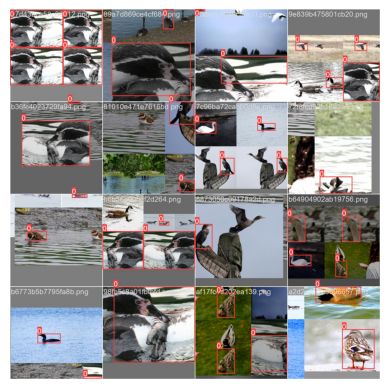

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
output_image = mpimg.imread('/content/runs/detect/train/train_batch0.jpg')
plt.imshow(output_image)
plt.axis('off')  # Hide axis
plt.show()

### yolov8n initialized from scratch on train2 data (400 images)

In [ ]:
model2 = YOLO('yolov8n.yaml')  # build a new model from YAML
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model2.train(data='/content/drive/MyDrive/archive/train2/config.yaml', epochs=30)

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=/content/drive/MyDrive/archive/train2/config.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=T

train: Scanning /content/drive/MyDrive/archive/labels/train.cache... 400 images, 0 backgrounds, 0 corrupt: 100%|██████████| 400/400 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
val: Scanning /content/drive/MyDrive/archive/labels/val.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]


Plotting labels to runs/detect/train3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train3
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30      2.35G      1.989      2.533      2.541         15        640: 100%|██████████| 25/25 [00:13<00:00,  1.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.51it/s]

                   all         50         52      0.557      0.346      0.369      0.145



30 epochs completed in 0.142 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 6.2MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.10it/s]


                   all         50         52      0.558      0.346      0.357      0.142
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/train3


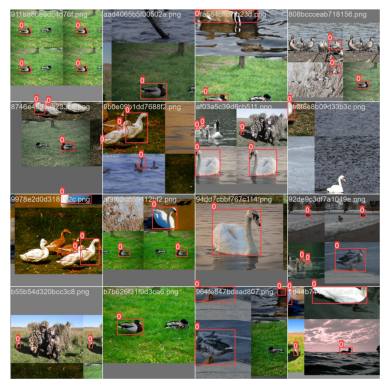

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
output_image = mpimg.imread('/content/runs/detect/train3/train_batch0.jpg')
plt.imshow(output_image)
plt.axis('off')  # Hide axis
plt.show()

### yolov8n from pretrained weights on train1 data (100 images)

In [ ]:
from ultralytics import YOLO
# Load a model
model3 = YOLO('yolov8n.pt')  # build a new model from YAML
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model3.train(data='/content/drive/MyDrive/archive/train1/config.yaml', epochs=30)

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/archive/train1/config.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tru

train: Scanning /content/drive/MyDrive/archive/train1/labels/train.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
val: Scanning /content/drive/MyDrive/archive/labels/val.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]


Plotting labels to runs/detect/train5/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train5
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30      2.43G     0.7488      1.473      1.012          4        640: 100%|██████████| 7/7 [00:01<00:00,  4.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.89it/s]

                   all         50         52      0.687      0.615      0.667       0.46



30 epochs completed in 0.036 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 6.2MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.96it/s]


                   all         50         52      0.686      0.615      0.662      0.459
Speed: 0.2ms preprocess, 3.8ms inference, 0.0ms loss, 5.2ms postprocess per image
Results saved to runs/detect/train5


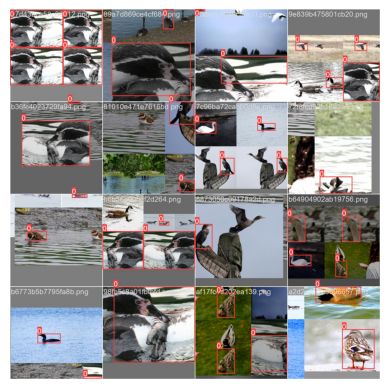

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
output_image = mpimg.imread('/content/runs/detect/train5/train_batch0.jpg')
plt.imshow(output_image)
plt.axis('off')  # Hide axis
plt.show()

### yolov8n from pretrained weights on train2 data (400 images)

In [ ]:
from ultralytics import YOLO
# Load a model
model4 = YOLO('yolov8n.pt')  # build a new model from YAML
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model4.train(data='/content/drive/MyDrive/archive/config.yaml', epochs=30)

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/archive/config.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show

train: Scanning /content/drive/MyDrive/archive/labels/train.cache... 400 images, 0 backgrounds, 0 corrupt: 100%|██████████| 400/400 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
val: Scanning /content/drive/MyDrive/archive/labels/val.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]


Plotting labels to runs/detect/train7/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train7
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30      2.25G     0.7092     0.9743      1.037         15        640: 100%|██████████| 25/25 [00:13<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.54it/s]

                   all         50         52      0.722       0.75      0.735      0.579



30 epochs completed in 0.140 hours.
Optimizer stripped from runs/detect/train7/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train7/weights/best.pt, 6.2MB

Validating runs/detect/train7/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.85it/s]


                   all         50         52      0.732      0.769      0.747      0.586
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs/detect/train7


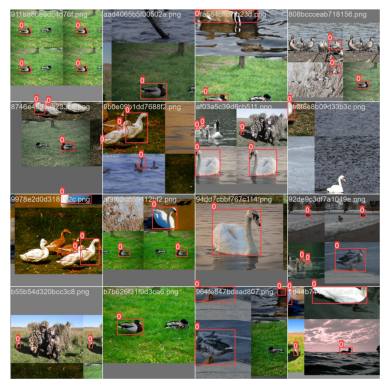

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
output_image = mpimg.imread('/content/runs/detect/train7/train_batch0.jpg')
plt.imshow(output_image)
plt.axis('off')  # Hide axis
plt.show()

### yolov8m from pretrained weights on train1 data (100 images)

In [ ]:
from ultralytics import YOLO
# Load a model
model5 = YOLO('yolov8m.pt')  # build a new model from YAML
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model5.train(data='/content/drive/MyDrive/archive/train1/config.yaml', epochs=30)

100%|██████████| 49.7M/49.7M [00:00<00:00, 221MB/s]


Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/archive/train1/config.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tru

train: Scanning /content/drive/MyDrive/archive/train1/labels/train.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
val: Scanning /content/drive/MyDrive/archive/labels/val.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]


...

      30/30      7.35G     0.9007      1.179      1.195          4        640: 100%|██████████| 7/7 [00:03<00:00,  2.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.64it/s]

                   all         50         52      0.613      0.457      0.475      0.302



30 epochs completed in 0.054 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train8/weights/best.pt, 52.0MB

Validating runs/detect/train8/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25840339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.33it/s]


                   all         50         52      0.721      0.654      0.714      0.643
Speed: 0.3ms preprocess, 9.4ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to runs/detect/train8


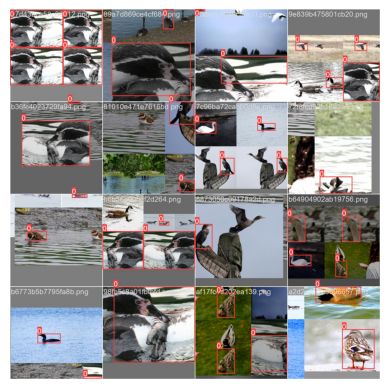

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
output_image = mpimg.imread('/content/runs/detect/train8/train_batch0.jpg')
plt.imshow(output_image)
plt.axis('off')  # Hide axis
plt.show()

### yolov8m from pretrained weights on train2 data (400 images)

In [ ]:
from ultralytics import YOLO
# Load a model
model6 = YOLO('yolov8m.pt')  # build a new model from YAML
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model6.train(data='/content/drive/MyDrive/archive/config.yaml', epochs=30)

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/archive/config.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show

train: Scanning /content/drive/MyDrive/archive/labels/train.cache... 400 images, 0 backgrounds, 0 corrupt: 100%|██████████| 400/400 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
val: Scanning /content/drive/MyDrive/archive/labels/val.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]


Plotting labels to runs/detect/train9/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train9
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30      7.88G     0.7953      1.099      1.165         15        640: 100%|██████████| 25/25 [00:16<00:00,  1.55it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.85it/s]

                   all         50         52      0.746      0.623      0.687      0.543



30 epochs completed in 0.214 hours.
Optimizer stripped from runs/detect/train9/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train9/weights/best.pt, 52.0MB

Validating runs/detect/train9/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25840339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.02it/s]


                   all         50         52      0.657       0.75      0.729       0.55
Speed: 0.2ms preprocess, 9.2ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs/detect/train9


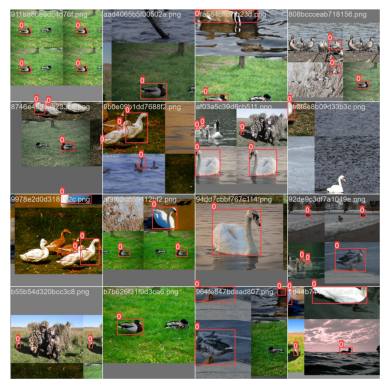

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
output_image = mpimg.imread('/content/runs/detect/train9/train_batch0.jpg')
plt.imshow(output_image)
plt.axis('off')  # Hide axis
plt.show()

| Model Name | mAP on training set | mAP on validation set |
|----------|----------|----------|
| yolov8n initialized from scratch on 100 images| 0.054 | 0.0569 |
| yolov8n initialized from scratch on 400 images | 0.369 | 0.357 |
| yolov8n from pretrained weights on 100 images | 0.667 | 0.662 |
| yolov8n from pretrained weights on 400 images |  0.735  | 0.747 |
| yolov8m from pretrained weights on 100 images | 0.475 | 0.714 |
| yolov8m from pretrained weights on 400 images | 0.737 | 0.729 |

### (a) How does increasing dataset size impact performance?

Increasing the dataset size generally improves the performance of the model. We can observe this trend in the provided results:

- For yolov8n initialized from scratch, the mAP on both the training and validation sets increases as the dataset size increases from 100 images to 400 images.
- For yolov8n from pretrained weights, a similar trend is observed, with higher mAP values achieved on both sets when trained on a larger dataset (100 images vs. 400 images).
- For yolov8m from pretrained weights, there is a substantial increase in mAP when trained on a larger dataset (100 images vs. 400 images).

Increasing the dataset size provides more diverse examples for the model to learn from, enabling it to generalize better to unseen data. It helps the model capture a wider range of variations and complexities present in real-world scenarios, leading to improved performance.



### (b) Does the bigger model perform better? Why or why not?

The bigger model (yolov8m) does not always perform better than the smaller model (yolov8n). While yolov8m achieves higher mAP on the training set when pretrained on 100 images, it performs worse on the validation set compared to yolov8n. This suggests overfitting, where the larger model captures too much detail from the training data, making it less generalizable to unseen data.

Additionally, the performance of the model depends not only on its size but also on factors such as the quality of pretrained weights, dataset size, and task complexity. In some cases, a smaller model with carefully initialized weights or trained on a larger dataset might outperform a larger model. Therefore, it's essential to consider various factors and perform empirical evaluation to determine the optimal model for a given task.

### 4 images from the validation set

In [ ]:
model4.predict(
   source='/content/drive/MyDrive/archive/images/val/',
   conf=0.25
)


image 1/50 /content/drive/MyDrive/archive/images/val/01211d4bbc161694.png: 416x640 1 duck, 169.5ms
image 2/50 /content/drive/MyDrive/archive/images/val/0142d1fc46883a7b.png: 448x640 2 ducks, 60.0ms
image 3/50 /content/drive/MyDrive/archive/images/val/01fdd867ec430d2b.png: 448x640 2 ducks, 12.8ms
image 4/50 /content/drive/MyDrive/archive/images/val/02b336d12bc20674.png: 448x640 1 duck, 13.3ms
image 5/50 /content/drive/MyDrive/archive/images/val/033a2d3f9eac6188.png: 416x640 (no detections), 12.8ms
image 6/50 /content/drive/MyDrive/archive/images/val/0419be7677df9e33.png: 480x640 1 duck, 59.0ms
image 7/50 /content/drive/MyDrive/archive/images/val/051d7ef8b9480b4f.png: 640x448 1 duck, 74.7ms
image 8/50 /content/drive/MyDrive/archive/images/val/0555911ee31d049f.png: 448x640 1 duck, 13.8ms
image 9/50 /content/drive/MyDrive/archive/images/val/05684a325a320136.png: 480x640 1 duck, 13.8ms
image 10/50 /content/drive/MyDrive/archive/images/val/0a411d151f978818.png: 480x640 2 ducks, 13.9ms
image

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'duck'}
 obb: None
 orig_img: array([[[229, 224, 225],
         [229, 224, 225],
         [229, 224, 225],
         ...,
         [ 75, 105, 110],
         [ 73, 105, 111],
         [ 72, 104, 110]],
 
        [[228, 223, 224],
         [228, 223, 224],
         [228, 223, 224],
         ...,
         [ 70, 100, 105],
         [ 71, 100, 107],
         [ 70,  99, 106]],
 
        [[228, 222, 223],
         [228, 222, 223],
         [228, 222, 223],
         ...,
         [ 67,  96, 103],
         [ 67,  96, 103],
         [ 65,  94, 101]],
 
        ...,
 
        [[238, 237, 239],
         [238, 237, 239],
         [238, 237, 239],
         ...,
         [251, 255, 255],
         [250, 255, 254],
         [250, 255, 254]],
 
        [[239, 238, 240],
         [239, 238, 240],
         [238, 237, 239],
         ...,
         [250, 254, 

### Prediction

In [ ]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='/content/drive/MyDrive/archive/images/val/0a411d151f978818.png'

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/drive/MyDrive/archive/images/val/0a411d151f978818.png: 480x640 2 birds, 2 frisbees, 76.5ms
Speed: 39.2ms preprocess, 76.5ms inference, 4475.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='/content/drive/MyDrive/archive/images/val/033a2d3f9eac6188.png'

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/drive/MyDrive/archive/images/val/033a2d3f9eac6188.png: 416x640 1 bird, 93.6ms
Speed: 41.0ms preprocess, 93.6ms inference, 4791.9ms postprocess per image at shape (1, 3, 416, 640)
Results saved to runs/detect/predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='/content/drive/MyDrive/archive/images/val/22c17fb1411ee176.png'

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/drive/MyDrive/archive/images/val/22c17fb1411ee176.png: 640x448 1 bird, 95.8ms
Speed: 46.1ms preprocess, 95.8ms inference, 4317.0ms postprocess per image at shape (1, 3, 640, 448)
Results saved to runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [ ]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='/content/drive/MyDrive/archive/images/val/3bf985c5f7e90b7d.png'

Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/drive/MyDrive/archive/images/val/3bf985c5f7e90b7d.png: 448x640 1 person, 1 bird, 1 frisbee, 76.5ms
Speed: 36.4ms preprocess, 76.5ms inference, 4242.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/detect/predict5
💡 Learn more at https://docs.ultralytics.com/modes/predict


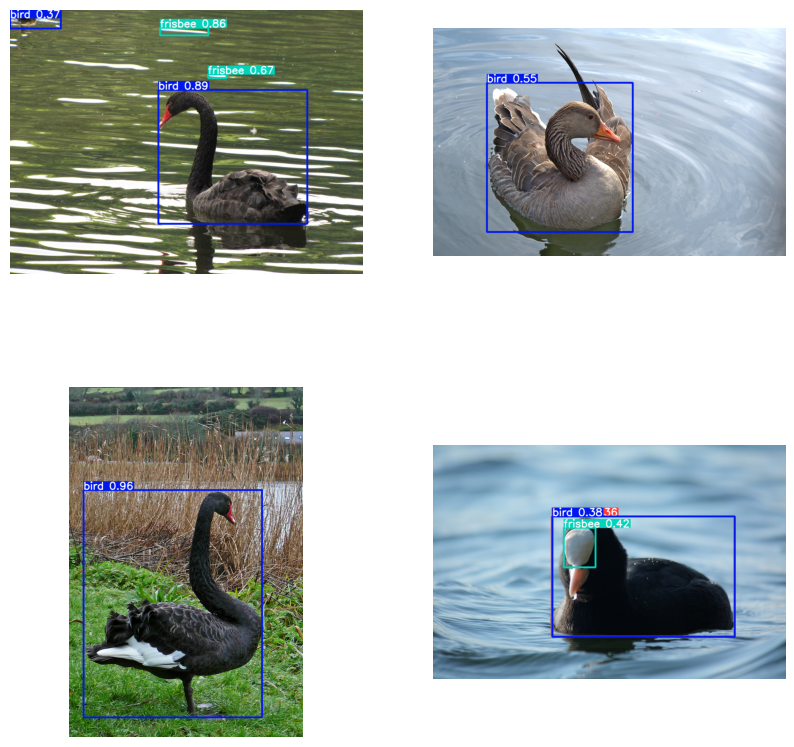

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

output_image1 = mpimg.imread('/content/runs/detect/predict2/0a411d151f978818.png')
axs[0, 0].imshow(output_image1)
axs[0, 0].axis('off')

output_image2 = mpimg.imread('/content/runs/detect/predict3/033a2d3f9eac6188.png')
axs[0, 1].imshow(output_image2)
axs[0, 1].axis('off')

output_image3 = mpimg.imread('/content/runs/detect/predict4/22c17fb1411ee176.png')
axs[1, 0].imshow(output_image3)
axs[1, 0].axis('off')

output_image4 = mpimg.imread('/content/runs/detect/predict5/3bf985c5f7e90b7d.png')
axs[1, 1].imshow(output_image4)
axs[1, 1].axis('off')

plt.show()


## Part 5

#### (i) Does the default run use augmentations? Which ones and what do they do?

The default run appears to use augmentations during training. Specifically, it utilizes the Albumentations library for data augmentation, which includes the following augmentations:

- Blur: Adds blur to the images with a probability of 0.01 and a blur limit ranging from 3 to 7.
- MedianBlur: Applies median blur with a probability of 0.01 and a blur limit ranging from 3 to 7.
- ToGray: Converts images to grayscale with a probability of 0.01.
- CLAHE: Applies Contrast Limited Adaptive Histogram Equalization (CLAHE) with a probability of 0.01, a clip limit ranging from 1 to 4.0, and a tile grid size of 8x8.

These augmentations are applied to the training images to introduce variations and improve the robustness of the model during training.

In [4]:
from ultralytics import YOLO
# Load a model
model3 = YOLO('yolov8n.pt')  # build a new model from YAML, 8n model, pt on 100 images
#model = YOLO('yolov8n.pt')  # load a pretrained model (recommended for training)
#model = YOLO('yolov8n.yaml').load('yolov8n.pt')  # build from YAML and transfer weights

# Train the model
results = model3.train(data='/content/drive/MyDrive/archive/train1/config.yaml', epochs=30, hsv_h = 0, hsv_s = 0, hsv_v = 0, translate = 0, scale = 0, fliplr = 0, mosaic = 0, auto_augment = 0, erasing = 0, crop_fraction = 0)

100%|██████████| 6.23M/6.23M [00:00<00:00, 51.5MB/s]


Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/archive/train1/config.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, s

100%|██████████| 755k/755k [00:00<00:00, 15.8MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/archive/train1/labels/train.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]


...

      30/30         0G     0.1403     0.5073     0.7909          4        640: 100%|██████████| 7/7 [01:21<00:00, 11.68s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:13<00:00,  6.97s/it]

                   all         50         52      0.707      0.604      0.632       0.37



30 epochs completed in 0.831 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.1.45 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:13<00:00,  6.64s/it]


                   all         50         52    0.00333      0.962      0.644      0.478
Speed: 2.2ms preprocess, 207.0ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to runs/detect/train


### (ii) Is the change significant? If yes, why? If not, why?

### Without Augmentation:
- **Epochs Completed**: 30

- **Training Results**:

  - mAP50: 0.632
  

### With Augmentation:
- **Epochs Completed**: 30

- **Training Results**:
  
  - mAP50: 0.667


### Notes:
- Augmentation seems to have increased GPU memory usage significantly.
- With augmentation, losses appear to be higher, but mAP50 seems to have slightly improved.
- Both settings seem to have relatively low precision but high recall, indicating potential for improvement in localization accuracy.
- The model with augmentation might be more robust as it has been trained with more challenging variations of the data due to augmentation.


### (iii) Which augmentation is the most important? How did you determine this?

Certain augmentation techniques are commonly considered more important or impactful based on their ability to introduce variations that help improve model generalization. 

- Horizontal Flipping: Helps the model learn invariant features and doubles the dataset size.
- Rotation: Introduces robustness to rotational changes in real-world scenarios.
- Scaling and Translation: Makes the model invariant to changes in scale and position.
- Color Jittering: Helps the model become invariant to variations in lighting conditions and color distributions.
- Random Cropping: Introduces variability in the spatial location of objects, aiding the model in recognizing objects in different contexts and scales.